In [1]:
%load_ext autoreload
%autoreload 2

import os
from PIL import Image, ImageOps
import requests
import torch
import matplotlib.pyplot as plt
import numpy as np

import torch
import requests
from tqdm import tqdm
from io import BytesIO
from diffusers import StableDiffusionInpaintPipeline
import torchvision.transforms as T

from utils import preprocess, prepare_mask_and_masked_image, recover_image

In [2]:
to_pil = T.ToPILImage()

In [4]:
""" this shouid print
torch        1.12.1+cu113
diffusers    0.10.2
np           1.23.5
"""
import diffusers
for k,v in dict(torch=torch, diffusers=diffusers, np=np).items():
    print(f"{k:<12} {v.__version__}")

torch        1.12.1+cu113
diffusers    0.10.2
np           1.23.5


### First lets instantiate an inpainting stable diffusion model

In [48]:
# make sure you're logged in with `huggingface-cli login` - check https://github.com/huggingface/diffusers for more details
# since runwayml has yanked its models, <"runwayml/stable-diffusion-inpainting"> lets use a different inpainting model
# eg. stable-diffusion-v1-5/stable-diffusion-inpainting"
# tested with stabilityai/stable-diffusion-2-inpainting, with weird results
modelid = "stable-diffusion-v1-5/stable-diffusion-inpainting"
# no     revision="fp16", 
pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    modelid,
    torch_dtype=torch.float16,
)
pipe_inpaint = pipe_inpaint.to("cuda")

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

### The image to fake

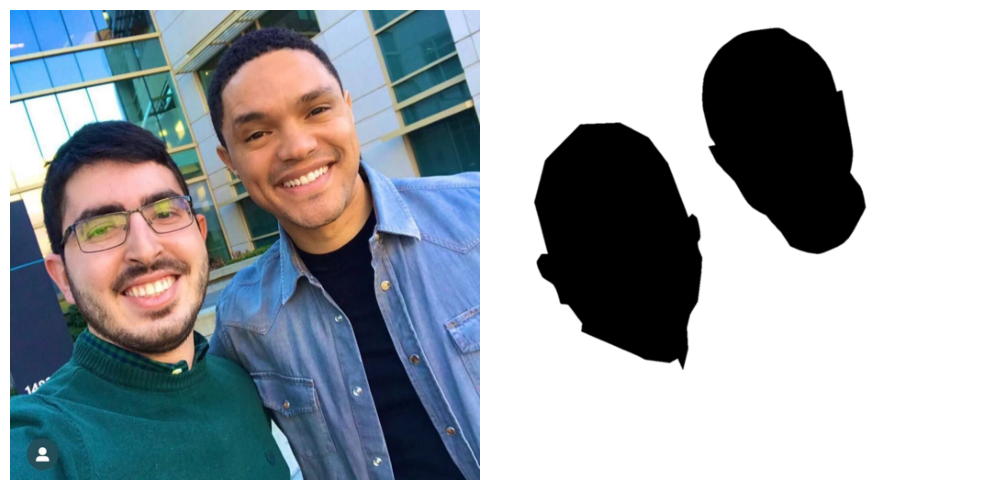

In [17]:
init_image = Image.open(f'../assets/trevor_5.jpg').convert('RGB').resize((512,512))
mask_image = Image.open(f'../assets/trevor_5.tif').convert('RGB')
mask_image = ImageOps.invert(mask_image).resize((512,512))

plt.figure(figsize=(10,5))
plt.subplot(121);plt.imshow(init_image);plt.axis('off')
plt.subplot(122);plt.imshow(mask_image);plt.axis('off')
plt.tight_layout();plt.show()

### Running Stable Diffusion Inpainting

In [43]:
# prompt = "man riding a motorcycle at night"
# prompt = "two men in a wedding"
# prompt = "two men in a restaurant hugging"
# prompt = "two men in a classroom"
# prompt = "two men in a library"
prompt = "two men on a plane hugging" # changed 'in the' to 'on the' 

# A good seed
SEED = 9209

# Uncomment the below to generated other images
# SEED = np.random.randint(low=0, high=100000)

torch.manual_seed(SEED)
print(SEED)

strength = 0.7
guidance_scale = 7.5
num_inference_steps = 100

image_nat = pipe_inpaint(prompt=prompt, 
                     image=init_image, 
                     mask_image=mask_image, 
                     eta=1,
                     num_inference_steps=num_inference_steps,
                     guidance_scale=guidance_scale,
                     num_images_per_prompt=5,
                     # strength=strength
                    )

9209


  0%|          | 0/100 [00:00<?, ?it/s]

In [44]:
images_nat = [recover_image(im, init_image, mask_image) for im in image_nat.images]
print(len(images_nat))

5


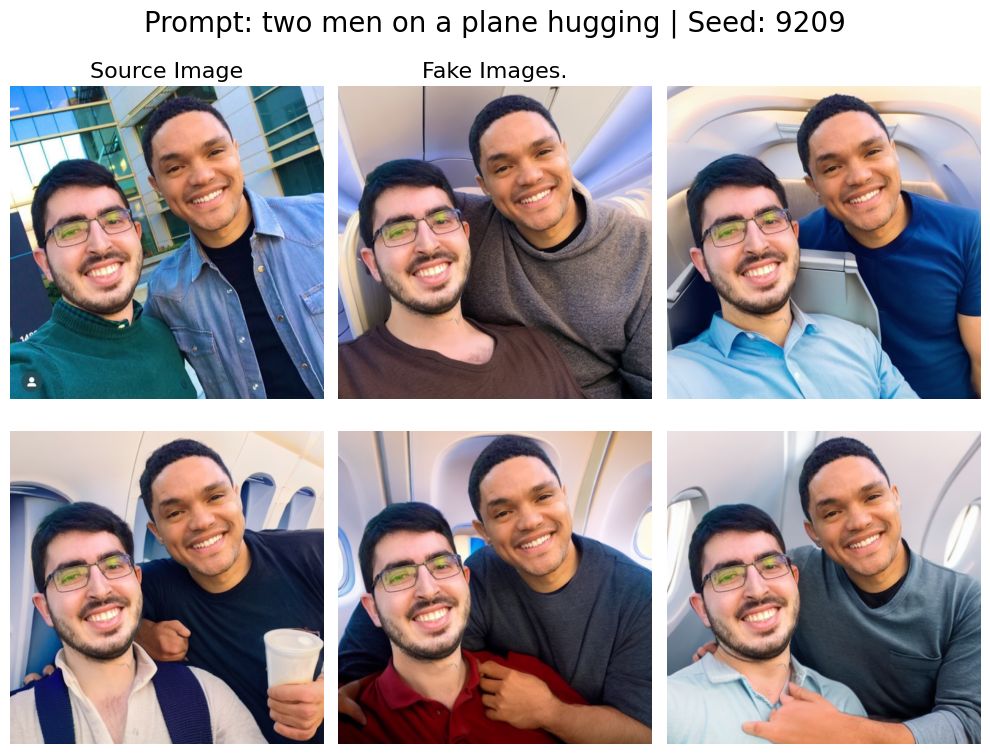

In [47]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10,8))

i,j=0,0
ax[0,0].imshow(init_image);
ax[0,0].axis('off')
for i in range(1,6):
    ax[i//3,i%3].imshow(images_nat[i-1])
    ax[i//3,i%3].axis('off')

ax[0,0].set_title('Source Image', fontsize=16)
ax[0,1].set_title('Fake Images.', fontsize=16)
    
fig.suptitle(f"Prompt: {prompt} | Seed: {SEED}", fontsize=20)
fig.tight_layout()
plt.show()